# Handling Categorical Data (Feature Transformation)

## What is Categorical Data?

In machine learning, data is mainly divided into **two types**:

### 1️⃣ Numerical Data
Data represented by numbers.
- Age, Salary, Temperature, Number of purchases

### 2️⃣ Categorical Data
Data that represents **categories or labels**.
- Gender, City, Product Category, Movie Genre

---

## Types of Categorical Data

### 🔹 Nominal Data (No Order)
Categories that have **no ranking or order**.

| Example | Categories |
|---------|-----------|
| Movie Genre 🎬 | Action, Comedy, Horror, Drama |
| Car Brand 🚗 | Toyota, BMW, Honda, Ford |

### 🔹 Ordinal Data (Has Order)
Categories that have a **meaningful order/ranking**.

| Example | Order |
|---------|-------|
| Movie Rating ⭐ | Poor < Average < Good < Excellent |
| Delivery Speed 🚚 | Slow < Normal < Fast |

---

## Why Encoding is Required?

- Categorical data is stored as **text (strings)** → `"Action"`, `"Comedy"`, `"Poor"`
- But **ML algorithms only understand numbers**
- So we must convert categories into **numerical values**
- This process is called **Encoding**

---

## Encoding Techniques Summary

| Encoding Method | Used For | Applied To |
|----------------|----------|------------|
| **Ordinal Encoding** | Ordered categories | Input features (X) |
| **One-Hot Encoding** | Unordered categories | Input features (X) |
| **Label Encoding** | Target categories | Target variable (y) |

# Step 1: Create the Movie Recommendation Dataset

Our dataset has these columns:

| Column | Type | Values |
|--------|------|--------|
| **Age** | Numerical | 18, 25, 35... |
| **Genre** | Nominal (no order) | Action, Comedy, Horror |
| **Rating** | Ordinal (has order) | Poor < Average < Good < Excellent |
| **Subscription** | Ordinal (has order) | Free < Premium < VIP |
| **Liked Movie** | Nominal Target (y) | Yes / No |

### Encoding Strategy:
| Column | Encoding Method |
|--------|----------------|
| Genre | **One-Hot Encoding** |
| Rating | **Ordinal Encoding** |
| Subscription | **Ordinal Encoding** |
| Liked Movie (target) | **Label Encoding** |

In [2]:
import pandas as pd

# Create the movie recommendation dataset
data = {
    'Age': [22, 35, 28, 45, 19, 50, 33, 27, 41, 23, 38, 31, 26, 44, 20],
    'Genre': ['Action', 'Comedy', 'Horror', 'Comedy', 'Action', 'Horror', 'Comedy', 'Action', 'Horror', 'Comedy', 'Action', 'Horror', 'Comedy', 'Action', 'Horror'],
    'Rating': ['Good', 'Excellent', 'Average', 'Good', 'Poor', 'Excellent', 'Good', 'Average', 'Excellent', 'Poor', 'Good', 'Average', 'Excellent', 'Good', 'Poor'],
    'Subscription': ['Free', 'VIP', 'Premium', 'VIP', 'Free', 'Premium', 'VIP', 'Free', 'Premium', 'Free', 'VIP', 'Premium', 'VIP', 'Premium', 'Free'],
    'Liked_Movie': ['Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print("Shape:", df.shape)
print("\nDataset:")
df
df_copy = df.copy()  # Create a copy for encoding

Shape: (15, 5)

Dataset:


In [3]:
df.head()

,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,Good,Free,Yes
1,35,Comedy,Excellent,VIP,Yes
2,28,Horror,Average,Premium,No
3,45,Comedy,Good,VIP,Yes
4,19,Action,Poor,Free,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           15 non-null     int64
 1   Genre         15 non-null     str  
 2   Rating        15 non-null     str  
 3   Subscription  15 non-null     str  
 4   Liked_Movie   15 non-null     str  
dtypes: int64(1), str(4)
memory usage: 732.0 bytes


In [5]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
Age             int64
Genre             str
Rating            str
Subscription      str
Liked_Movie       str
dtype: object


In [6]:
df

,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,Good,Free,Yes
1,35,Comedy,Excellent,VIP,Yes
2,28,Horror,Average,Premium,No
3,45,Comedy,Good,VIP,Yes
4,19,Action,Poor,Free,No
5,50,Horror,Excellent,Premium,Yes
6,33,Comedy,Good,VIP,Yes
7,27,Action,Average,Free,No
8,41,Horror,Excellent,Premium,Yes
9,23,Comedy,Poor,Free,No


In [7]:
print("\n--- Unique values in each categorical column ---")
for col in ['Genre', 'Rating', 'Subscription', 'Liked_Movie']:
    print(f"\n{col}: {df[col].unique()}")


--- Unique values in each categorical column ---

Genre: <StringArray>
['Action', 'Comedy', 'Horror']
Length: 3, dtype: str

Rating: <StringArray>
['Good', 'Excellent', 'Average', 'Poor']
Length: 4, dtype: str

Subscription: <StringArray>
['Free', 'VIP', 'Premium']
Length: 3, dtype: str

Liked_Movie: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


# Step 2: Ordinal Encoding (For Ordered Categories)

**Used for:** Categories that have a **meaningful order/ranking**

### In our dataset:
- **Rating**: Poor(0) < Average(1) < Good(2) < Excellent(3)
- **Subscription**: Free(0) < Premium(1) < VIP(2)

### How it works:
Each category is replaced with a number that **respects the order**.

```
Rating:        Poor → 0,  Average → 1,  Good → 2,  Excellent → 3
Subscription:  Free → 0,  Premium → 1,  VIP → 2
```

### ⚠️ Important:
You must **define the order yourself** — the algorithm doesn't know the order automatically!

In [8]:
df.head()

,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,Good,Free,Yes
1,35,Comedy,Excellent,VIP,Yes
2,28,Horror,Average,Premium,No
3,45,Comedy,Good,VIP,Yes
4,19,Action,Poor,Free,No


In [10]:
from sklearn.preprocessing import OrdinalEncoder

rating_order = ['Poor', 'Average', 'Good', 'Excellent']        # 0, 1, 2, 3
subscription_order = ['Free', 'Premium', 'VIP']                 # 0, 1, 2

# Create OrdinalEncoder with defined categories
oe = OrdinalEncoder(categories=[rating_order, subscription_order])

# Apply ordinal encoding on Rating and Subscription columns
df[['Rating', 'Subscription']] = oe.fit_transform(df[['Rating', 'Subscription']])

print("After Ordinal Encoding:")
print("\nRating mapping:      Poor=0, Average=1, Good=2, Excellent=3")
print("Subscription mapping: Free=0, Premium=1, VIP=2")
print()
df

After Ordinal Encoding:

Rating mapping:      Poor=0, Average=1, Good=2, Excellent=3
Subscription mapping: Free=0, Premium=1, VIP=2



,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,2.0,0.0,Yes
1,35,Comedy,3.0,2.0,Yes
2,28,Horror,1.0,1.0,No
3,45,Comedy,2.0,2.0,Yes
4,19,Action,0.0,0.0,No
5,50,Horror,3.0,1.0,Yes
6,33,Comedy,2.0,2.0,Yes
7,27,Action,1.0,0.0,No
8,41,Horror,3.0,1.0,Yes
9,23,Comedy,0.0,0.0,No


# Step 3: Label Encoding (For Target Variable)

**Used for:** The **target variable (y)** in classification problems.

### In our dataset:
- **Liked_Movie**: Yes / No → This is our target (what we want to predict)

### How it works:
```
Yes → 1
No  → 0
```

### Label Encoding vs Ordinal Encoding:
| Feature | Ordinal Encoding | Label Encoding |
|---------|-----------------|----------------|
| Used for | Input features (X) | Target variable (y) |
| Order matters? | Yes, you define it | No, just converts to numbers |
| Class | `OrdinalEncoder` | `LabelEncoder` |

### Common use cases for Label Encoding:
- Spam / Not Spam 📧
- Fraud / Not Fraud 💳
- Liked / Not Liked 👍👎
- Disease / No Disease 🏥

In [11]:
df[['Liked_Movie']]

,Liked_Movie
0,Yes
1,Yes
2,No
3,Yes
4,No
5,Yes
6,Yes
7,No
8,Yes
9,No


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply Label Encoding on target variable
df['Liked_Movie'] = le.fit_transform(df['Liked_Movie'])

print("Label Encoding mapping:")

for i , value in enumerate(le.classes_):
    print(f"  {i} → {value}")

print("\nDataset after Label Encoding target:")
df

Label Encoding mapping:
  0 → No
  1 → Yes

Dataset after Label Encoding target:


,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,2.0,0.0,1
1,35,Comedy,3.0,2.0,1
2,28,Horror,1.0,1.0,0
3,45,Comedy,2.0,2.0,1
4,19,Action,0.0,0.0,0
5,50,Horror,3.0,1.0,1
6,33,Comedy,2.0,2.0,1
7,27,Action,1.0,0.0,0
8,41,Horror,3.0,1.0,1
9,23,Comedy,0.0,0.0,0


# Step 4: One-Hot Encoding (For Unordered Categories)

**Used for:** Categories that have **NO order/ranking** (Nominal Data)

### In our dataset:
- **Genre**: Action, Comedy, Horror → No ranking!

### How it works:
Each category becomes a **new column** with values **0 or 1**.

```
Genre_Action  Genre_Comedy  Genre_Horror
   1              0             0          → Action
   0              1             0          → Comedy
   0              0             1          → Horror
```

### Why not use Ordinal Encoding for Nominal Data?
If we assign: Action=0, Comedy=1, Horror=2
- The model thinks Horror(2) > Comedy(1) > Action(0)
- But there is **NO such ranking** among genres!
- This creates **wrong relationships** in the model

### ⚠️ Dummy Variable Trap
When using One-Hot Encoding, we usually **drop one column** (`drop='first'`).
- Why? Because if Genre is NOT Action and NOT Comedy → it MUST be Horror
- Keeping all columns creates **multicollinearity** (redundant information)

In [13]:
df[['Genre']]

,Genre
0,Action
1,Comedy
2,Horror
3,Comedy
4,Action
5,Horror
6,Comedy
7,Action
8,Horror
9,Comedy


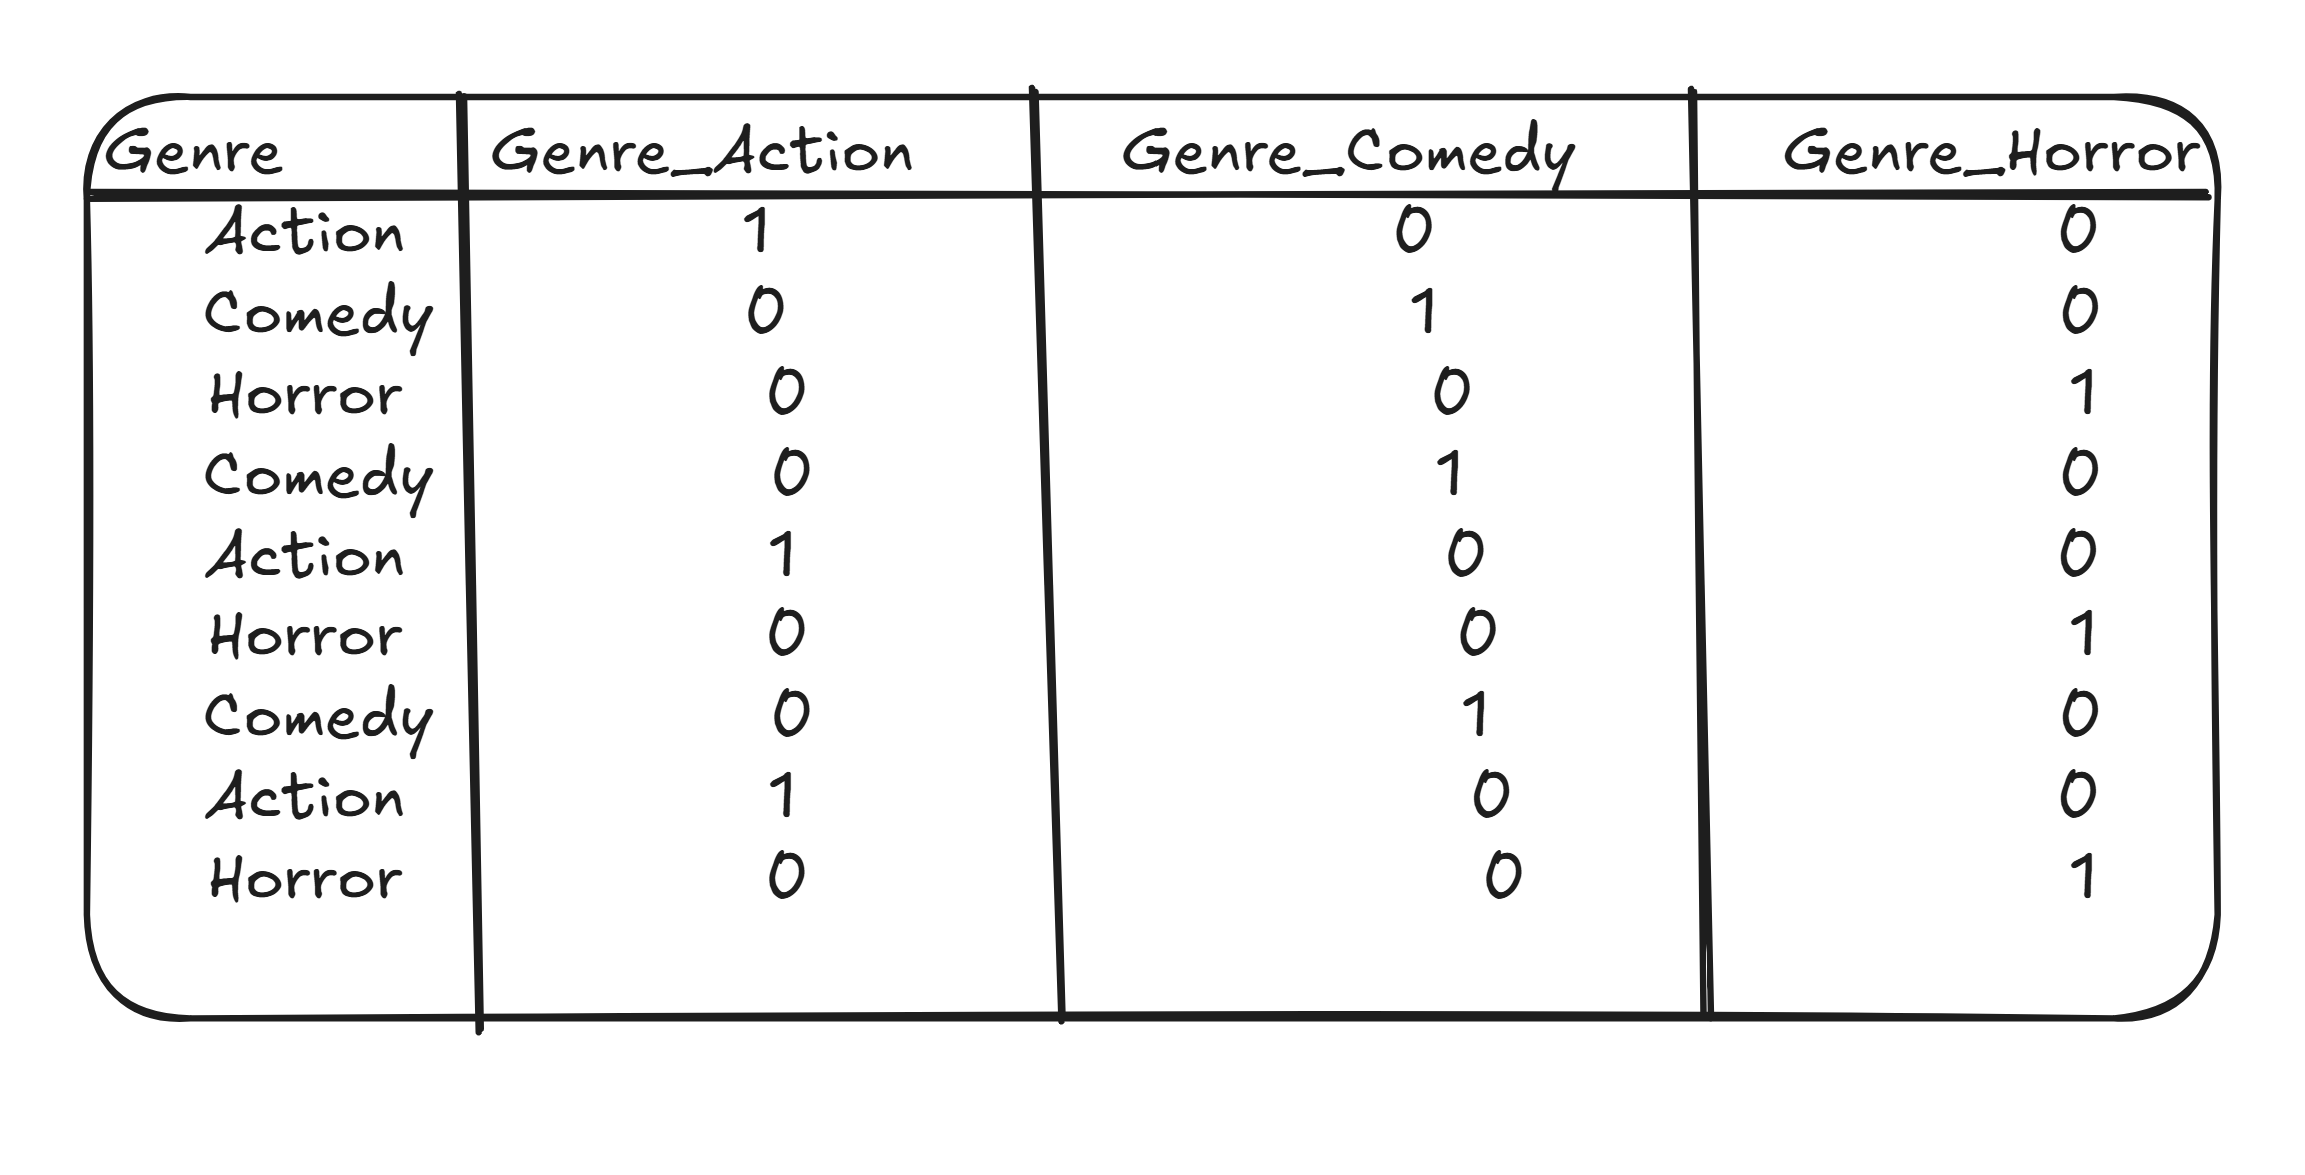

In [14]:
from sklearn.preprocessing import OneHotEncoder

# Create OneHotEncoder (drop='first' to avoid dummy variable trap)
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Apply on Genre column
genre_encoded = ohe.fit_transform(df[['Genre']])

# Get the new column names
genre_columns = ohe.get_feature_names_out(['Genre'])
print("New columns created:", genre_columns)

# Create a DataFrame with encoded values
genre_df = pd.DataFrame(genre_encoded.astype(int), columns=genre_columns, index=df.index)
print("\nOne-Hot Encoded Genre:")
genre_df

New columns created: ['Genre_Comedy' 'Genre_Horror']

One-Hot Encoded Genre:


,Genre_Comedy,Genre_Horror
0,0,0
1,1,0
2,0,1
3,1,0
4,0,0
5,0,1
6,1,0
7,0,0
8,0,1
9,1,0


In [15]:
# Combine encoded Genre with original dataframe
df_encoded = pd.concat([df.drop('Genre', axis=1), genre_df], axis=1)

print("Dataset after One-Hot Encoding Genre:")
df_encoded

Dataset after One-Hot Encoding Genre:


,Age,Rating,Subscription,Liked_Movie,Genre_Comedy,Genre_Horror
0,22,2.0,0.0,1,0,0
1,35,3.0,2.0,1,1,0
2,28,1.0,1.0,0,0,1
3,45,2.0,2.0,1,1,0
4,19,0.0,0.0,0,0,0
5,50,3.0,1.0,1,0,1
6,33,2.0,2.0,1,1,0
7,27,1.0,0.0,0,0,0
8,41,3.0,1.0,1,0,1
9,23,0.0,0.0,0,1,0


In [16]:
df_copy.head()

,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,Good,Free,Yes
1,35,Comedy,Excellent,VIP,Yes
2,28,Horror,Average,Premium,No
3,45,Comedy,Good,VIP,Yes
4,19,Action,Poor,Free,No


#  Step 5: ColumnTransformer (Do Everything in One Step!)

### The Problem:
In real projects, you have **many columns** and each needs **different encoding**.
- Doing it one by one is **messy and error-prone**
- Hard to use in **ML pipelines**

### The Solution: `ColumnTransformer`
It lets you apply **different transformations to different columns** in **one step**!

```python
ColumnTransformer([
    ('name1', Transformer1(), [columns]),
    ('name2', Transformer2(), [columns]),
], remainder='passthrough')   # Keep other columns as-is
```

### For our dataset:
```
ColumnTransformer([
    ('ohe',  OneHotEncoder(drop='first'),                                   ['Genre']),
    ('oe',   OrdinalEncoder(categories=[rating_order, subscription_order]), ['Rating', 'Subscription']),
], remainder='passthrough')   # Keeps 'Age' as-is
```

In [ ]:
from sklearn.compose import ColumnTransformer

# ---- Separate features (X) and target (y) ----
X = df_copy.drop('Liked_Movie', axis=1) #Remove column from df and put the new df in x
y = df_copy['Liked_Movie']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   Age   Genre     Rating Subscription
0   22  Action       Good         Free
1   35  Comedy  Excellent          VIP
2   28  Horror    Average      Premium
3   45  Comedy       Good          VIP
4   19  Action       Poor         Free

Target (y):
0    Yes
1    Yes
2     No
3    Yes
4     No
Name: Liked_Movie, dtype: str


In [ ]:
# ---- Define ColumnTransformer ----
# Apply different encoding to different columns in ONE step!

rating_order = ['Poor', 'Average', 'Good', 'Excellent']
subscription_order = ['Free', 'Premium', 'VIP']

ct = ColumnTransformer([
    # (name, transformer, columns)
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['Genre']),                          # Nominal → One-Hot
    ('oe',  OrdinalEncoder(categories=[rating_order, subscription_order]), ['Rating', 'Subscription']),  # Ordinal → Ordinal Encoding
], remainder='passthrough')   # 'Age' column passes through unchanged

# Transform features
X_transformed = ct.fit_transform(X)

# Get column names
ohe_cols = ct.named_transformers_['ohe'].get_feature_names_out(['Genre'])
all_columns = list(ohe_cols) + ['Rating', 'Subscription', 'Age'] # Should always be in the same chronology as the encoders inside columnTransfomer

X_final = pd.DataFrame(X_transformed, columns=all_columns)
print("ColumnTransformer applied!")
print(f"   Columns: {all_columns}")
X_final

ColumnTransformer applied!
   Columns: ['Genre_Comedy', 'Genre_Horror', 'Rating', 'Subscription', 'Age']


,Genre_Comedy,Genre_Horror,Rating,Subscription,Age
0,0.0,0.0,2.0,0.0,22.0
1,1.0,0.0,3.0,2.0,35.0
2,0.0,1.0,1.0,1.0,28.0
3,1.0,0.0,2.0,2.0,45.0
4,0.0,0.0,0.0,0.0,19.0
5,0.0,1.0,3.0,1.0,50.0
6,1.0,0.0,2.0,2.0,33.0
7,0.0,0.0,1.0,0.0,27.0
8,0.0,1.0,3.0,1.0,41.0
9,1.0,0.0,0.0,0.0,23.0


# 🚀 Step 6: Real-World ML Process (Train-Test Split + Encoding Pipeline)

### In real projects, the correct workflow is:

```
1. Separate X and y
2. Train-Test Split  ← BEFORE encoding!
3. Define ColumnTransformer
4. fit_transform() on X_train only
5. transform() on X_test (NO fit!)
6. Label encode y_train and y_test
```

### ⚠️ Why split BEFORE encoding?
- If you encode BEFORE splitting → **data leakage!**
- Test data info leaks into training through the encoder
- Rule: **fit on train, transform on both**

In [ ]:
df_copy.head()


,Age,Genre,Rating,Subscription,Liked_Movie
0,22,Action,Good,Free,Yes
1,35,Comedy,Excellent,VIP,Yes
2,28,Horror,Average,Premium,No
3,45,Comedy,Good,VIP,Yes
4,19,Action,Poor,Free,No


In [28]:
from sklearn.model_selection import train_test_split

# ---- Step A: Use df_copy (fresh original data) ----
X = df_copy.drop('Liked_Movie', axis=1)
y = df_copy['Liked_Movie']

# ---- Step B: Train-Test Split (BEFORE encoding!) ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print("\nX_train (raw, before encoding):")
X_train

X_train: (12, 4)  |  X_test: (3, 4)
y_train: (12,)  |  y_test: (3,)

X_train (raw, before encoding):


,Age,Genre,Rating,Subscription
13,44,Action,Good,Premium
5,50,Horror,Excellent,Premium
8,41,Horror,Excellent,Premium
2,28,Horror,Average,Premium
1,35,Comedy,Excellent,VIP
14,20,Horror,Poor,Free
4,19,Action,Poor,Free
7,27,Action,Average,Free
10,38,Action,Good,VIP
12,26,Comedy,Excellent,VIP


In [ ]:
# ---- Step C: Define ColumnTransformer ----
rating_order = ['Poor', 'Average', 'Good', 'Excellent']
subscription_order = ['Free', 'Premium', 'VIP']

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), ['Genre']),
    ('oe',  OrdinalEncoder(categories=[rating_order, subscription_order]), ['Rating', 'Subscription']),
], remainder='passthrough')

# ---- Step D: fit_transform on TRAIN, transform on TEST ----
# IMPORTANT: fit only on training data to prevent data leakage!
X_train_encoded = ct.fit_transform(X_train)   # fit + transform
X_test_encoded  = ct.transform(X_test)         # only transform (NO fit!)

# Get column names
ohe_cols = ct.named_transformers_['ohe'].get_feature_names_out(['Genre'])
all_columns = list(ohe_cols) + ['Rating', 'Subscription', 'Age']

X_train_final = pd.DataFrame(X_train_encoded, columns=all_columns)
X_test_final  = pd.DataFrame(X_test_encoded, columns=all_columns)

print("X_train encoded:")
X_train_final

X_train encoded:


,Genre_Comedy,Genre_Horror,Rating,Subscription,Age
0,0.0,0.0,2.0,1.0,44.0
1,0.0,1.0,3.0,1.0,50.0
2,0.0,1.0,3.0,1.0,41.0
3,0.0,1.0,1.0,1.0,28.0
4,1.0,0.0,3.0,2.0,35.0
5,0.0,1.0,0.0,0.0,20.0
6,0.0,0.0,0.0,0.0,19.0
7,0.0,0.0,1.0,0.0,27.0
8,0.0,0.0,2.0,2.0,38.0
9,1.0,0.0,3.0,2.0,26.0


In [31]:
print("X_test encoded:")
X_test_final

X_test encoded:


,Genre_Comedy,Genre_Horror,Rating,Subscription,Age
0,1.0,0.0,0.0,0.0,23.0
1,0.0,1.0,1.0,1.0,31.0
2,0.0,0.0,2.0,0.0,22.0


In [32]:
# ---- Step E: Label Encode target variable ----
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)   # fit + transform on train
y_test_encoded  = le.transform(y_test)         # only transform on test

print("Target encoding:  No → 0,  Yes → 1")
print(f"\ny_train (before): {y_train.values}")
print(f"y_train (after):  {y_train_encoded}")
print(f"\ny_test (before):  {y_test.values}")
print(f"y_test (after):   {y_test_encoded}")

print("\n" + "="*55)
print(" ALL DONE! Data is encoded & split — ready for ML model!")
print("="*55)
print(f"\nX_train: {X_train_final.shape}  |  X_test: {X_test_final.shape}")
print(f"y_train: {y_train_encoded.shape}  |  y_test: {y_test_encoded.shape}")

Target encoding:  No → 0,  Yes → 1

y_train (before): ['Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes']
y_train (after):  [1 1 1 0 1 0 0 0 1 1 1 1]

y_test (before):  ['No' 'No' 'Yes']
y_test (after):   [0 0 1]

 ALL DONE! Data is encoded & split — ready for ML model!

X_train: (12, 5)  |  X_test: (3, 5)
y_train: (12,)  |  y_test: (3,)


# 📋 Complete Summary — Encoding Cheat Sheet

## Decision Flowchart:
```
Is it a TARGET variable (y)?
├── YES → Use Label Encoding
└── NO → Is there a natural ORDER?
         ├── YES → Use Ordinal Encoding
         └── NO  → Use One-Hot Encoding
```

## Quick Reference Table:

| Encoding | When to Use | Example | sklearn Class |
|----------|------------|---------|--------------|
| **Ordinal Encoding** | Ordered categories in **features (X)** | Rating: Poor→0, Average→1, Good→2 | `OrdinalEncoder` |
| **One-Hot Encoding** | Unordered categories in **features (X)** | Genre: Action→[1,0], Comedy→[0,1] | `OneHotEncoder` |
| **Label Encoding** | Categories in **target (y)** | Liked: Yes→1, No→0 | `LabelEncoder` |

## Key Points to Remember:
1. **Never use Ordinal Encoding on Nominal data** → creates false order
2. **Use `drop='first'` in One-Hot Encoding** → avoids dummy variable trap
3. **ColumnTransformer** → applies different encodings to different columns in one step
4. **Label Encoding is ONLY for target variable** → not for features
5. **Define order explicitly** in Ordinal Encoding → model doesn't know your order
6. **Always split BEFORE encoding** → prevents data leakage
7. **fit on train, transform on both** → golden rule